In [34]:
import numpy as np
import pandas as pd
import joblib
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# # ACPI Interval Narrowing for Electric Motor Temperature Prediction
#
# This notebook demonstrates how to generate counterfactual explanations that:
# 1. Maintain prediction interval coverage (uncertainty quantification)
# 2. Reduce interval width for more precise predictions
# 3. Respect physical constraints of motor operation
#
# **Dataset**: Permanent Magnet Synchronous Motor (PMSM) sensor measurements
# **Goal**: Optimize motor operating conditions to achieve narrower temperature prediction intervals


In [35]:
class PyTorchACPIWrapper:
    """Wrapper to make PyTorch models compatible with ACPI."""
    def __init__(self, model, device='cpu'):
        self.model = model
        self.device = device
        self.model.eval()

    def predict(self, X):
        """Predict using the PyTorch model."""
        if isinstance(X, np.ndarray):
            X_tensor = torch.tensor(X, dtype=torch.float32, device=self.device)
        else:
            X_tensor = X

        with torch.no_grad():
            predictions = self.model(X_tensor)

        return predictions.cpu().numpy()

In [36]:
# Configuration
DATA_PATH = "../data/ElectricMotorTemperature.csv"  # Adjust path as needed
TARGET_COL = "pm"  # Permanent magnet temperature
CONTEXT_LENGTH = 12  # Use 12 timesteps (6 seconds at 2Hz) for temporal context
ALPHA = 0.1  # 90% prediction intervals

# Features to use
SENSOR_FEATURES = ['ambient', 'coolant', 'u_d', 'u_q', 'motor_speed', 'torque', 'i_d', 'i_q']
TARGET_FEATURES = ['stator_yoke', 'stator_tooth', 'stator_winding']


# ## Data Loading and Preparation


In [37]:
def load_motor_data(filepath, sample_frac=0.3, random_state=42):
    """
    Load and prepare motor temperature data.

    Args:
        filepath: Path to CSV file
        sample_frac: Fraction of data to sample (for computational efficiency)
        random_state: Random seed

    Returns:
        DataFrame with motor sensor data
    """
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)

    # Sample data for efficiency (185 hours is large)
    if sample_frac < 1.0:
        df = df.sample(frac=sample_frac, random_state=random_state).sort_index()

    print(f"Loaded {len(df)} samples")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nData shape: {df.shape}")
    print(f"Time span: {len(df) / 2 / 3600:.2f} hours (at 2Hz)")

    return df

def build_temporal_sequences(df, feature_cols, target_col, context_length):
    """
    Build sliding window sequences for time-series prediction.

    Args:
        df: Input dataframe
        feature_cols: List of feature column names
        target_col: Target variable name
        context_length: Number of past timesteps to use

    Returns:
        X: Feature sequences (n_samples, context_length * n_features)
        y: Target values (n_samples,)
    """
    print(f"\nBuilding temporal sequences with context length {context_length}...")

    features = df[feature_cols].values
    target = df[target_col].values

    X_sequences = []
    y_sequences = []

    # Create sliding windows
    for i in range(context_length, len(df)):
        # Get past context_length timesteps
        X_window = features[i - context_length:i].flatten()
        y_target = target[i]

        X_sequences.append(X_window)
        y_sequences.append(y_target)

    X = np.array(X_sequences, dtype=np.float32)
    y = np.array(y_sequences, dtype=np.float32)

    print(f"Created {len(X)} sequences")
    print(f"Feature dimension: {X.shape[1]} ({context_length} timesteps × {len(feature_cols)} features)")

    return X, y


In [38]:
# Load data
motor_df = load_motor_data(DATA_PATH, sample_frac=0.3)

# Select features
feature_cols = SENSOR_FEATURES + TARGET_FEATURES
print(f"\nUsing {len(feature_cols)} features: {feature_cols}")

# Build sequences
X_all, y_all = build_temporal_sequences(motor_df, feature_cols, TARGET_COL, CONTEXT_LENGTH)

# Normalize features
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

# Time-based split (motor data is sequential)
train_size = 0.7
val_size = 0.15
test_size = 0.15

n_train = int(len(X_all_scaled) * train_size)
n_val = int(len(X_all_scaled) * val_size)

X_train = X_all_scaled[:n_train]
y_train = y_all[:n_train]

X_val = X_all_scaled[n_train:n_train + n_val]
y_val = y_all[n_train:n_train + n_val]

X_test = X_all_scaled[n_train + n_val:]
y_test = y_all[n_train + n_val:]

print(f"\nData splits:")
print(f"  Train: {len(X_train)} samples")
print(f"  Val:   {len(X_val)} samples")
print(f"  Test:  {len(X_test)} samples")

# Further split test into calibration and evaluation
cal_size = 0.5
n_cal = int(len(X_test) * cal_size)

X_cal = X_test[:n_cal]
y_cal = y_test[:n_cal]

X_eval = X_test[n_cal:]
y_eval = y_test[n_cal:]

print(f"\nTest split for ACPI:")
print(f"  Calibration: {len(X_cal)} samples")
print(f"  Evaluation:  {len(X_eval)} samples")


Loading data from ../data/ElectricMotorTemperature.csv...
Loaded 399245 samples
Columns: ['u_q', 'coolant', 'stator_winding', 'u_d', 'stator_tooth', 'motor_speed', 'i_d', 'i_q', 'pm', 'stator_yoke', 'ambient', 'torque', 'profile_id']

Data shape: (399245, 13)
Time span: 55.45 hours (at 2Hz)

Using 11 features: ['ambient', 'coolant', 'u_d', 'u_q', 'motor_speed', 'torque', 'i_d', 'i_q', 'stator_yoke', 'stator_tooth', 'stator_winding']

Building temporal sequences with context length 12...
Created 399233 sequences
Feature dimension: 132 (12 timesteps × 11 features)

Data splits:
  Train: 279463 samples
  Val:   59884 samples
  Test:  59886 samples

Test split for ACPI:
  Calibration: 29943 samples
  Evaluation:  29943 samples


# ## Define Physical Constraints
#
# Motor operation has physical limits that must be respected:


In [39]:
# Define immutable features (cannot be changed)
# Profile ID and session info would be immutable, but we focus on control variables

# Define operational constraints based on motor physics
def get_motor_constraints(feature_cols, context_length):
    """
    Define feasible ranges for motor operating parameters.

    Returns:
        lower_bounds: Minimum values for each feature
        upper_bounds: Maximum values for each feature
        immutable_mask: Boolean mask for features that cannot be changed
    """
    n_features = len(feature_cols)
    sequence_length = context_length * n_features

    # Define per-feature constraints (these are example values - adjust based on motor specs)
    feature_constraints = {
        'ambient': (10, 50),        # Ambient temperature (°C)
        'coolant': (10, 50),        # Coolant temperature (°C)
        'u_d': (-500, 500),         # d-axis voltage
        'u_q': (-500, 500),         # q-axis voltage
        'motor_speed': (-5000, 5000),  # Motor speed (rpm)
        'torque': (-300, 300),      # Torque (Nm)
        'i_d': (-300, 300),         # d-axis current
        'i_q': (-300, 300),         # q-axis current
        'stator_yoke': (20, 150),   # Stator yoke temperature (°C)
        'stator_tooth': (20, 150),  # Stator tooth temperature (°C)
        'stator_winding': (20, 200) # Stator winding temperature (°C)
    }

    # Build bounds arrays
    lower_bounds = np.zeros(sequence_length)
    upper_bounds = np.zeros(sequence_length)

    for feat_idx, feat_name in enumerate(feature_cols):
        if feat_name in feature_constraints:
            lb, ub = feature_constraints[feat_name]
            for lag in range(context_length):
                pos = lag * n_features + feat_idx
                lower_bounds[pos] = lb
                upper_bounds[pos] = ub
        else:
            # Default wide bounds if not specified
            for lag in range(context_length):
                pos = lag * n_features + feat_idx
                lower_bounds[pos] = -1e6
                upper_bounds[pos] = 1e6

    # Immutable features: we can typically change control inputs but not all measurements
    # For this example, we'll make ambient temperature immutable (external condition)
    immutable_features = ['ambient']
    immutable_mask = np.zeros(sequence_length, dtype=bool)

    for feat_name in immutable_features:
        if feat_name in feature_cols:
            feat_idx = feature_cols.index(feat_name)
            for lag in range(context_length):
                pos = lag * n_features + feat_idx
                immutable_mask[pos] = True

    print(f"\nPhysical constraints defined:")
    print(f"  Immutable features: {immutable_features}")
    print(f"  Immutable positions: {np.sum(immutable_mask)} / {sequence_length}")

    return lower_bounds, upper_bounds, immutable_mask

# Get constraints
lower_bounds, upper_bounds, immutable_mask = get_motor_constraints(feature_cols, CONTEXT_LENGTH)



Physical constraints defined:
  Immutable features: ['ambient']
  Immutable positions: 12 / 132


# ## Load Pre-trained ACPI Model
#
# Assuming you have a trained ACPI model. If not, you'll need to train one first.


In [48]:
import joblib

# Load the trained ACPI model
ACPI_MODEL_PATH = "./models/acpi_motor_torque_model.pkl"

try:
    print(f"Loading ACPI model from {ACPI_MODEL_PATH}...")
    acpi_save_dict = joblib.load(ACPI_MODEL_PATH)

    acpi_model = acpi_save_dict['acpi_model']
    pytorch_wrapper = acpi_save_dict['pytorch_wrapper']
    x_scaler = acpi_save_dict['scaler_x']
    y_scaler = acpi_save_dict['scaler_y']

    print("✓ Loaded pre-trained ACPI model")
    print(f"  Features: {acpi_save_dict['feature_names']}")
    print(f"  Target: {acpi_save_dict['target_name']}")

    # Wrap for the generator
    class ACPIWrapper:
        def __init__(self, acpi_model):
            self.acpi_model = acpi_model

        def predict_pi(self, X, method='qrf'):
            return self.acpi_model.predict_pi(X, method=method)

    acpi_model = ACPIWrapper(acpi_model)

except FileNotFoundError:
    print(f"ERROR: ACPI model not found at {ACPI_MODEL_PATH}")
    print("Please run MotorTempACPI_RF.ipynb first to train and save the model.")
    raise

Loading ACPI model from ./models/acpi_motor_pm_temperature_model.pkl...
ERROR: ACPI model not found at ./models/acpi_motor_pm_temperature_model.pkl
Please run the PM temperature model training section in MotorTempACPI_RF.ipynb first.


FileNotFoundError: [Errno 2] No such file or directory: './models/acpi_motor_pm_temperature_model.pkl'

# ## Generative VAE for Counterfactual Generation


In [41]:
class MotorCounterfactualGenerator:
    """
    VAE-based counterfactual generator optimized for motor temperature control.
    Generates alternative operating conditions that produce narrower prediction intervals.
    """
    def __init__(self, prediction_model, device, alpha=0.1, latent_dim=16):
        self.prediction_model = prediction_model
        self.device = device
        self.alpha = alpha
        self.latent_dim = latent_dim
        self.vae = None
        self.is_trained = False

    def _build_vae(self, input_dim):
        """Build VAE architecture suitable for motor control sequences."""
        class MotorVAE(nn.Module):
            def __init__(self, input_dim, latent_dim, hidden_dim=256):
                super().__init__()
                self.input_dim = input_dim
                self.latent_dim = latent_dim

                # Encoder
                self.encoder = nn.Sequential(
                    nn.Linear(input_dim, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(hidden_dim, hidden_dim // 2),
                    nn.LayerNorm(hidden_dim // 2),
                    nn.ReLU(),
                    nn.Dropout(0.2)
                )
                self.mu_layer = nn.Linear(hidden_dim // 2, latent_dim)
                self.logvar_layer = nn.Linear(hidden_dim // 2, latent_dim)

                # Decoder
                self.decoder = nn.Sequential(
                    nn.Linear(latent_dim, hidden_dim // 2),
                    nn.LayerNorm(hidden_dim // 2),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(hidden_dim // 2, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(0.2),
                    nn.Linear(hidden_dim, input_dim)
                )

                self.apply(self._init_weights)

            def _init_weights(self, module):
                if isinstance(module, nn.Linear):
                    torch.nn.init.xavier_uniform_(module.weight)
                    if module.bias is not None:
                        torch.nn.init.zeros_(module.bias)

            def encode(self, x):
                h = self.encoder(x)
                mu = self.mu_layer(h)
                logvar = torch.clamp(self.logvar_layer(h), min=-10, max=10)
                return mu, logvar

            def reparameterize(self, mu, logvar):
                std = torch.exp(0.5 * logvar)
                eps = torch.randn_like(std)
                return mu + eps * std

            def decode(self, z):
                return self.decoder(z)

            def forward(self, x):
                mu, logvar = self.encode(x)
                z = self.reparameterize(mu, logvar)
                recon = self.decode(z)
                return recon, mu, logvar, z

        return MotorVAE(input_dim, self.latent_dim).to(self.device)

    def train_vae(self, X_sequences, epochs=300, batch_size=128, lr=1e-3, beta=0.05):
        """Train VAE on motor operating sequences."""
        print("\nTraining VAE for motor counterfactual generation...")
        X_sequences = np.asarray(X_sequences, dtype=np.float32)

        # Normalize
        self.mean_X = np.mean(X_sequences, axis=0, keepdims=True)
        self.std_X = np.std(X_sequences, axis=0, keepdims=True) + 1e-8
        X_normalized = (X_sequences - self.mean_X) / self.std_X

        # Build model
        input_dim = X_sequences.shape[1]
        self.vae = self._build_vae(input_dim)
        optimizer = torch.optim.AdamW(self.vae.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        dataset = TensorDataset(torch.tensor(X_normalized, dtype=torch.float32))
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

        self.vae.train()
        for epoch in range(epochs):
            total_loss = 0
            total_recon = 0
            total_kl = 0

            for (batch_x,) in dataloader:
                batch_x = batch_x.to(self.device)
                optimizer.zero_grad()

                recon, mu, logvar, _ = self.vae(batch_x)

                # Reconstruction loss
                recon_loss = nn.functional.mse_loss(recon, batch_x, reduction='mean')

                # KL divergence
                kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

                # Combined loss with beta weighting for KL
                loss = recon_loss + beta * kl_loss

                if torch.isnan(loss):
                    continue

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.vae.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss += loss.item()
                total_recon += recon_loss.item()
                total_kl += kl_loss.item()

            scheduler.step()

            avg_loss = total_loss / len(dataloader)
            avg_recon = total_recon / len(dataloader)
            avg_kl = total_kl / len(dataloader)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | "
                      f"Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}")

        self.vae.eval()
        self.is_trained = True
        print("VAE training completed!")

    def _normalize_input(self, x):
        return (x - self.mean_X) / self.std_X

    def _denormalize_output(self, x_norm):
        return x_norm * self.std_X + self.mean_X

    def generate_narrower_intervals(self, x_orig, y_true, current_lower, current_upper,
                                   n_samples=5000, exploration_std=0.3,
                                   lower_bounds=None, upper_bounds=None,
                                   immutable_mask=None, target_reduction=0.7):
        """
        Generate counterfactuals for narrower temperature prediction intervals.

        Args:
            x_orig: Original operating sequence
            y_true: True temperature value
            current_lower, current_upper: Current prediction interval
            n_samples: Number of candidates to generate
            exploration_std: Exploration noise in latent space
            lower_bounds, upper_bounds: Physical constraints
            immutable_mask: Features that cannot be changed
            target_reduction: Target width reduction (e.g., 0.7 means 30% narrower)

        Returns:
            Dictionary with optimization results
        """
        if not self.is_trained:
            raise ValueError("VAE must be trained before generating counterfactuals!")

        x_orig_np = np.asarray(x_orig, dtype=np.float32)
        x_orig_norm = self._normalize_input(x_orig_np)
        x_orig_t = torch.tensor(x_orig_norm, device=self.device, dtype=torch.float32)

        current_width = current_upper - current_lower
        target_width = current_width * target_reduction

        # Encode original to latent space
        with torch.no_grad():
            mu_orig, _ = self.vae.encode(x_orig_t.unsqueeze(0))
            if torch.isnan(mu_orig).any():
                mu_orig = torch.zeros_like(mu_orig)

        successful_results = []

        for _ in range(n_samples):
            # Sample from latent space
            with torch.no_grad():
                z_sample = mu_orig + exploration_std * torch.randn_like(mu_orig)
                x_cf_norm = self.vae.decode(z_sample).squeeze(0)

            x_cf_denorm = self._denormalize_output(x_cf_norm.cpu().numpy()).flatten()

            # Apply physical constraints
            if lower_bounds is not None:
                x_cf_denorm = np.maximum(x_cf_denorm, lower_bounds)
            if upper_bounds is not None:
                x_cf_denorm = np.minimum(x_cf_denorm, upper_bounds)
            if immutable_mask is not None:
                x_orig_flat = x_orig_np.flatten()
                x_cf_denorm[immutable_mask] = x_orig_flat[immutable_mask]

            # Get new prediction interval
            x_cf_input = x_cf_denorm.reshape(1, -1)
            y_lower_cf, y_upper_cf = self.prediction_model.predict_pi(x_cf_input, method='qrf')

            new_width = y_upper_cf[0] - y_lower_cf[0]

            # Check: maintains coverage AND narrower interval
            maintains_coverage = (y_lower_cf[0] <= y_true <= y_upper_cf[0])
            is_narrower = new_width < current_width

            if maintains_coverage and is_narrower:
                width_reduction_pct = (current_width - new_width) / current_width * 100

                result = {
                    "x_cf": x_cf_denorm,
                    "original_width": float(current_width),
                    "new_width": float(new_width),
                    "width_reduction": float(current_width - new_width),
                    "width_reduction_pct": float(width_reduction_pct),
                    "original_lower": float(current_lower),
                    "original_upper": float(current_upper),
                    "new_lower": float(y_lower_cf[0]),
                    "new_upper": float(y_upper_cf[0]),
                    "y_true": float(y_true),
                    "l1_distance": float(np.abs(x_cf_denorm - x_orig_np.flatten()).sum()),
                    "l2_distance": float(np.linalg.norm(x_cf_denorm - x_orig_np.flatten())),
                }
                successful_results.append(result)

        if not successful_results:
            return {"status": "no_improvement", "n_successful": 0, "results": []}

        # Sort by width reduction (best first)
        successful_results.sort(key=lambda x: x["width_reduction"], reverse=True)

        return {
            "status": "success",
            "n_successful": len(successful_results),
            "results": successful_results,
            "x_orig": x_orig_np.flatten(),
            "y_true": float(y_true),
            "original_interval": [float(current_lower), float(current_upper)]
        }


In [46]:
import os

#if a saved model exists, load it if not, train a new one
if os.path.exists("./models/motor_counterfactual_generator.pkl"):
    print("Loading saved VAE model...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    generator = MotorCounterfactualGenerator(
        prediction_model=acpi_model,
        device=device,
        alpha=ALPHA,
        latent_dim=20
    )
    generator.vae = generator._build_vae(X_train.shape[1])
    generator.vae.load_state_dict(torch.load("./models/motor_counterfactual_generator.pkl", map_location=device, weights_only=False))
    generator.is_trained = True
    print("Loaded saved VAE model.")
else:
    print("No saved VAE model found. Training a new one...")
    # Initialize generator
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {device}")

    generator = MotorCounterfactualGenerator(
        prediction_model=acpi_model,
        device=device,
        alpha=ALPHA,
        latent_dim=20
    )

    # Train VAE on training data
    print("\nTraining VAE on motor operating sequences...")
    generator.train_vae(X_train, epochs=300, batch_size=256, lr=1e-3, beta=0.05)
    #save the trained VAE model
    joblib.dump(generator.vae.state_dict(), "./models/motor_counterfactual_generator.pkl")
    print("Saved trained VAE model.")


Loading saved VAE model...
Loaded saved VAE model.


# ## Single Instance Optimization Demo


In [47]:
# Get baseline predictions
y_lower_baseline, y_upper_baseline = acpi_model.predict_pi(X_eval, method='qrf')
baseline_coverage = float(np.mean((y_eval >= y_lower_baseline) & (y_eval <= y_upper_baseline)))
baseline_width = float(np.mean(y_upper_baseline - y_lower_baseline))

print(f"\nBaseline Performance:")
print(f"  Coverage: {baseline_coverage:.4f} (target: {1-ALPHA:.4f})")
print(f"  Mean interval width: {baseline_width:.2f}°C")

# Select instance with wide interval for optimization
covered_mask = (y_eval >= y_lower_baseline) & (y_eval <= y_upper_baseline)
covered_idx = np.where(covered_mask)[0]
widths = y_upper_baseline - y_lower_baseline
covered_widths = widths[covered_idx]

# Pick instance with width above 75th percentile
width_75 = np.percentile(widths, 75)
wide_idx = covered_idx[covered_widths > width_75]

if len(wide_idx) > 0:
    demo_idx = np.random.choice(wide_idx)

    x_demo = X_eval[demo_idx]
    y_demo = y_eval[demo_idx]
    lower_demo = y_lower_baseline[demo_idx]
    upper_demo = y_upper_baseline[demo_idx]
    width_demo = upper_demo - lower_demo

    print(f"\n{'='*70}")
    print(f"SINGLE INSTANCE OPTIMIZATION DEMO")
    print(f"{'='*70}")
    print(f"\nSelected instance {demo_idx}:")
    print(f"  True PM temperature: {y_demo:.2f}°C")
    print(f"  Current interval: [{lower_demo:.2f}, {upper_demo:.2f}]°C")
    print(f"  Current width: {width_demo:.2f}°C")

    # Generate optimized operating conditions
    print(f"\nGenerating optimized motor operating conditions...")
    result = generator.generate_narrower_intervals(
        x_demo, y_demo, lower_demo, upper_demo,
        n_samples=8000,
        exploration_std=0.2,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        immutable_mask=immutable_mask,
        target_reduction=0.6
    )

    print(f"\nOptimization result: {result['status']}")
    print(f"Successful candidates: {result.get('n_successful', 0)}")

    if result['status'] == 'success' and result['n_successful'] > 0:
        best = result['results'][0]
        print(f"\n{'='*70}")
        print(f"BEST OPTIMIZATION FOUND")
        print(f"{'='*70}")
        print(f"  New interval: [{best['new_lower']:.2f}, {best['new_upper']:.2f}]°C")
        print(f"  New width: {best['new_width']:.2f}°C")
        print(f"  Width reduction: {best['width_reduction']:.2f}°C ({best['width_reduction_pct']:.1f}%)")
        print(f"  L1 change magnitude: {best['l1_distance']:.2f}")
        print(f"  Still covers true value: {best['new_lower']:.2f} ≤ {y_demo:.2f} ≤ {best['new_upper']:.2f}")


ValueError: X has 132 features, but RandomForestQuantileRegressor is expecting 11 features as input.

# ## Visualization Functions


In [11]:
def plot_motor_interval_comparison(original_interval, new_interval, y_true, title_suffix=""):
    """Visualize interval narrowing for motor temperature."""
    fig, ax = plt.subplots(figsize=(12, 6))

    orig_lower, orig_upper = original_interval
    new_lower, new_upper = new_interval

    # Plot intervals
    ax.barh(0, orig_upper - orig_lower, left=orig_lower, height=0.3,
            color='lightblue', alpha=0.7, label='Original Interval')
    ax.plot([orig_lower, orig_upper], [0, 0], 'b-', linewidth=4)

    ax.barh(1, new_upper - new_lower, left=new_lower, height=0.3,
            color='lightcoral', alpha=0.7, label='Optimized Interval')
    ax.plot([new_lower, new_upper], [1, 1], 'r-', linewidth=4)

    # True value
    ax.axvline(y_true, color='green', linestyle='--', linewidth=2.5,
               label=f'True PM Temp: {y_true:.1f}°C')

    # Annotations
    orig_width = orig_upper - orig_lower
    new_width = new_upper - new_lower
    reduction = (orig_width - new_width) / orig_width * 100

    ax.text(orig_lower + orig_width/2, 0, f'Width: {orig_width:.1f}°C',
            ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(new_lower + new_width/2, 1, f'Width: {new_width:.1f}°C\n↓{reduction:.1f}%',
            ha='center', va='center', fontsize=12, fontweight='bold', color='darkred')

    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Original', 'Optimized'], fontsize=13)
    ax.set_xlabel('PM Temperature (°C)', fontsize=14)
    ax.set_title(f'Motor Temperature Interval Optimization{title_suffix}', fontsize=16)
    ax.legend(fontsize=12, loc='upper right')
    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

def analyze_motor_feature_changes(x_orig, x_cf, context_length, feature_cols, top_n=5):
    """Analyze which motor operating parameters changed most."""
    n_features = len(feature_cols)
    x_orig_mat = x_orig.reshape(context_length, n_features)
    x_cf_mat = x_cf.reshape(context_length, n_features)

    # Calculate average change per feature across time
    delta = np.abs(x_cf_mat - x_orig_mat)
    avg_change = np.mean(delta, axis=0)

    # Sort by magnitude
    sorted_idx = np.argsort(avg_change)[::-1]

    print(f"\n{'='*70}")
    print(f"TOP {top_n} CHANGED MOTOR PARAMETERS")
    print(f"{'='*70}")

    for rank, idx in enumerate(sorted_idx[:top_n], 1):
        feat_name = feature_cols[idx]
        change_mag = avg_change[idx]
        orig_avg = np.mean(x_orig_mat[:, idx])
        new_avg = np.mean(x_cf_mat[:, idx])
        percent_change = (new_avg - orig_avg) / (abs(orig_avg) + 1e-8) * 100

        print(f"\n{rank}. {feat_name}")
        print(f"   Mean absolute change: {change_mag:.4f}")
        print(f"   Original average: {orig_avg:.4f}")
        print(f"   New average: {new_avg:.4f}")
        print(f"   Relative change: {percent_change:+.2f}%")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Original features
    sns.heatmap(x_orig_mat, ax=axes[0], cmap='viridis', cbar_kws={'label': 'Value'})
    axes[0].set_title('Original Operating Conditions', fontsize=14)
    axes[0].set_ylabel('Time Step', fontsize=12)
    axes[0].set_xlabel('Feature', fontsize=12)
    axes[0].set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)

    # Optimized features
    sns.heatmap(x_cf_mat, ax=axes[1], cmap='viridis', cbar_kws={'label': 'Value'})
    axes[1].set_title('Optimized Operating Conditions', fontsize=14)
    axes[1].set_ylabel('Time Step', fontsize=12)
    axes[1].set_xlabel('Feature', fontsize=12)
    axes[1].set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)

    # Changes
    change_matrix = x_cf_mat - x_orig_mat
    max_abs = np.max(np.abs(change_matrix))
    sns.heatmap(change_matrix, ax=axes[2], cmap='RdBu_r', center=0,
                vmin=-max_abs, vmax=max_abs, cbar_kws={'label': 'Change'})
    axes[2].set_title('Parameter Changes', fontsize=14)
    axes[2].set_ylabel('Time Step', fontsize=12)
    axes[2].set_xlabel('Feature', fontsize=12)
    axes[2].set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)

    plt.tight_layout()
    plt.show()


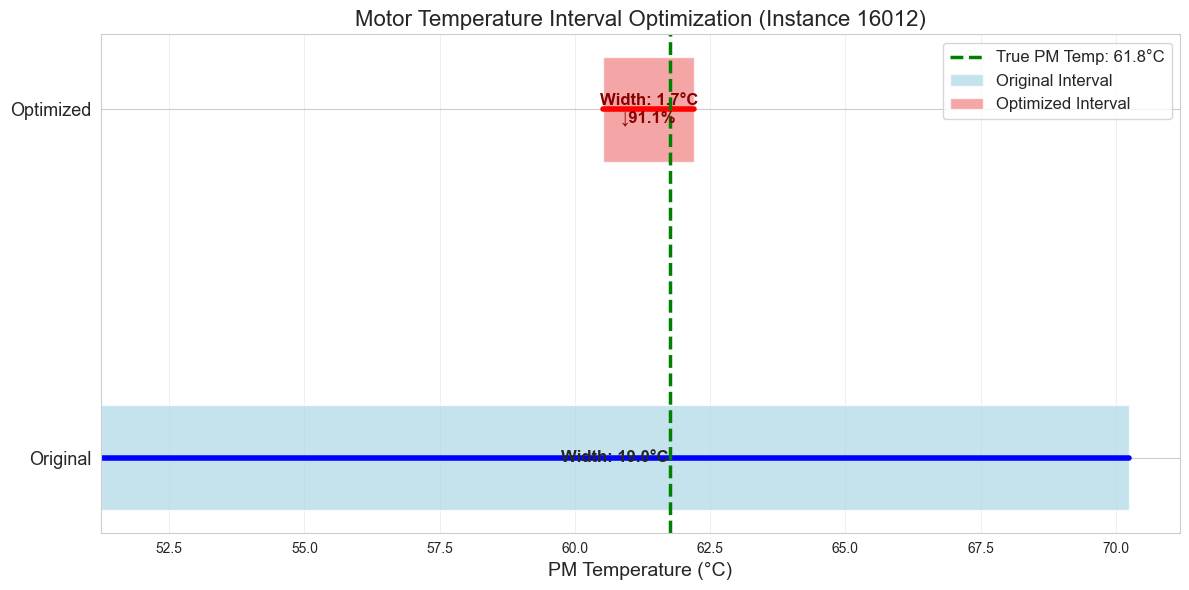


TOP 8 CHANGED MOTOR PARAMETERS

1. stator_yoke
   Mean absolute change: 20.2791
   Original average: -0.2791
   New average: 20.0000
   Relative change: +7265.38%

2. stator_tooth
   Mean absolute change: 20.1318
   Original average: -0.1318
   New average: 20.0000
   Relative change: +15278.92%

3. stator_winding
   Mean absolute change: 20.0814
   Original average: -0.0814
   New average: 20.0000
   Relative change: +24669.63%

4. coolant
   Mean absolute change: 10.4164
   Original average: -0.4164
   New average: 10.0000
   Relative change: +2501.73%

5. motor_speed
   Mean absolute change: 0.4833
   Original average: 0.8807
   New average: 0.3974
   Relative change: -54.88%

6. i_q
   Mean absolute change: 0.3716
   Original average: 0.3429
   New average: 0.7145
   Relative change: +108.39%

7. i_d
   Mean absolute change: 0.3269
   Original average: -0.6596
   New average: -0.3328
   Relative change: +49.55%

8. torque
   Mean absolute change: 0.3228
   Original average: 0.3847

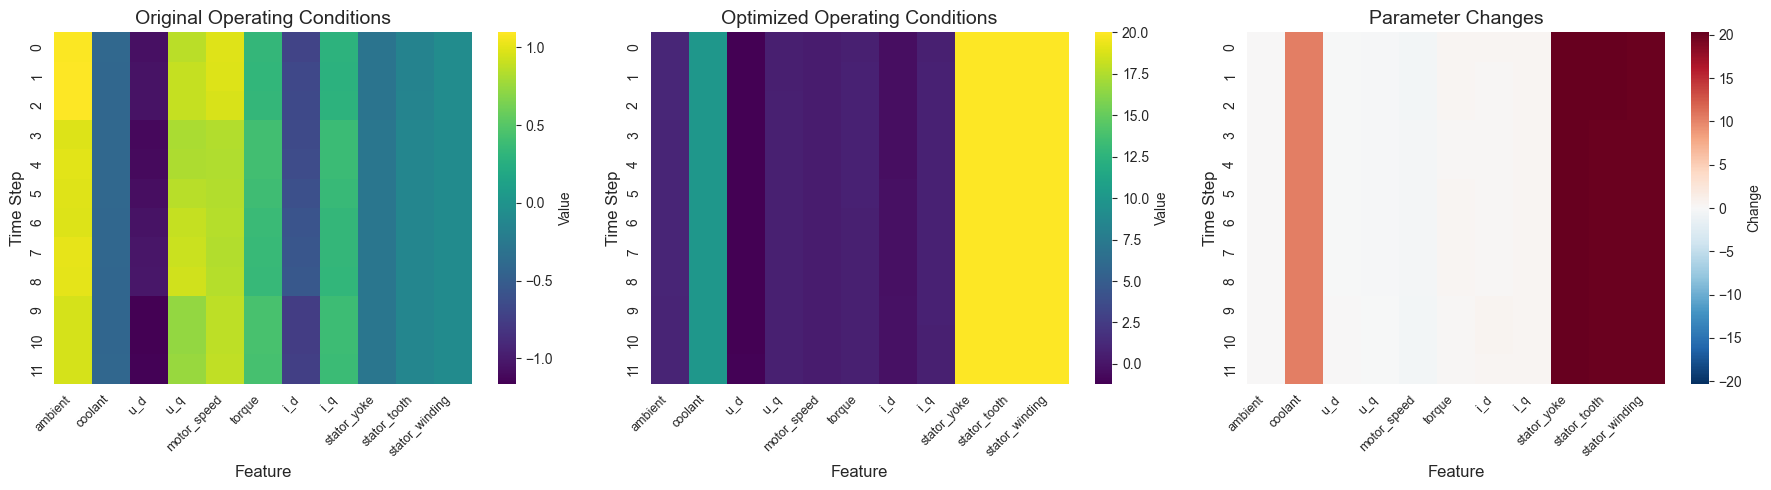

In [12]:
# Visualize the demo optimization
if result['status'] == 'success' and result['n_successful'] > 0:
    best = result['results'][0]

    plot_motor_interval_comparison(
        [best['original_lower'], best['original_upper']],
        [best['new_lower'], best['new_upper']],
        y_demo,
        title_suffix=f" (Instance {demo_idx})"
    )

    analyze_motor_feature_changes(
        result['x_orig'],
        best['x_cf'],
        CONTEXT_LENGTH,
        feature_cols,
        top_n=8
    )


# ## Batch Optimization


In [13]:
def optimize_motor_operations_batch(generator, acpi_model, X_eval, y_eval,
                                   lower_bounds, upper_bounds, immutable_mask,
                                   max_instances=30, n_samples=3000):
    """
    Optimize multiple motor operating sequences for narrower intervals.
    """
    print(f"\n{'='*70}")
    print(f"BATCH MOTOR OPERATION OPTIMIZATION")
    print(f"{'='*70}")

    # Get baseline
    y_lower, y_upper = acpi_model.predict_pi(X_eval, method='qrf')
    covered = (y_eval >= y_lower) & (y_eval <= y_upper)
    widths = y_upper - y_lower

    # Target wide intervals
    covered_idx = np.where(covered)[0]
    covered_widths = widths[covered_idx]
    sorted_idx = np.argsort(covered_widths)[::-1]
    target_idx = covered_idx[sorted_idx[:max_instances]]

    print(f"\nOptimizing {len(target_idx)} instances with widest intervals...")

    X_optimized = X_eval.copy()
    optimized_data = []

    for i, idx in enumerate(target_idx):
        if (i + 1) % 10 == 0:
            print(f"  Progress: {i+1}/{len(target_idx)}")

        x_orig = X_eval[idx]
        y_true = y_eval[idx]
        lower_orig = y_lower[idx]
        upper_orig = y_upper[idx]

        result = generator.generate_narrower_intervals(
            x_orig, y_true, lower_orig, upper_orig,
            n_samples=n_samples,
            exploration_std=0.2,
            lower_bounds=lower_bounds,
            upper_bounds=upper_bounds,
            immutable_mask=immutable_mask,
            target_reduction=0.65
        )

        if result['status'] == 'success' and result['n_successful'] > 0:
            best = result['results'][0]
            X_optimized[idx] = best['x_cf'].reshape(1, -1)

            optimized_data.append({
                'idx': idx,
                'original_width': best['original_width'],
                'new_width': best['new_width'],
                'reduction_pct': best['width_reduction_pct'],
                'y_true': y_true,
                'original_lower': lower_orig,
                'original_upper': upper_orig,
                'new_lower': best['new_lower'],
                'new_upper': best['new_upper']
            })

    # Recompute metrics
    y_lower_opt, y_upper_opt = acpi_model.predict_pi(X_optimized, method='qrf')
    coverage_opt = float(np.mean((y_eval >= y_lower_opt) & (y_eval <= y_upper_opt)))
    width_opt = float(np.mean(y_upper_opt - y_lower_opt))

    coverage_orig = float(np.mean(covered))
    width_orig = float(np.mean(widths))

    return {
        'X_optimized': X_optimized,
        'optimized_instances': optimized_data,
        'n_optimized': len(optimized_data),
        'original_coverage': coverage_orig,
        'optimized_coverage': coverage_opt,
        'original_width': width_orig,
        'optimized_width': width_opt,
        'width_reduction_pct': (width_orig - width_opt) / width_orig * 100
    }


In [14]:
# Run batch optimization
batch_results = optimize_motor_operations_batch(
    generator=generator,
    acpi_model=acpi_model,
    X_eval=X_eval,
    y_eval=y_eval,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    immutable_mask=immutable_mask,
    max_instances=30,
    n_samples=3000
)

print(f"\n{'='*70}")
print(f"BATCH OPTIMIZATION RESULTS")
print(f"{'='*70}")
print(f"\nInstances optimized: {batch_results['n_optimized']}")
print(f"\nCoverage:")
print(f"  Original:  {batch_results['original_coverage']:.4f}")
print(f"  Optimized: {batch_results['optimized_coverage']:.4f}")
print(f"\nMean Interval Width:")
print(f"  Original:  {batch_results['original_width']:.2f}°C")
print(f"  Optimized: {batch_results['optimized_width']:.2f}°C")
print(f"  Reduction: {batch_results['width_reduction_pct']:.1f}%")



BATCH MOTOR OPERATION OPTIMIZATION

Optimizing 30 instances with widest intervals...
  Progress: 10/30
  Progress: 20/30
  Progress: 30/30

BATCH OPTIMIZATION RESULTS

Instances optimized: 30

Coverage:
  Original:  0.1835
  Optimized: 0.1840

Mean Interval Width:
  Original:  14.99°C
  Optimized: 15.01°C
  Reduction: -0.1%


# ## Business Impact Summary


In [15]:
def create_motor_business_report(batch_results):
    """Generate business-focused report for motor operations."""
    print(f"\n{'='*70}")
    print(f"MOTOR OPERATION OPTIMIZATION - BUSINESS IMPACT")
    print(f"{'='*70}")

    print("\n📊 EXECUTIVE SUMMARY")
    print("-" * 70)
    print(f"  • Motor operating conditions optimized: {batch_results['n_optimized']}")
    print(f"  • Temperature prediction coverage: {batch_results['optimized_coverage']:.2%}")
    print(f"  • Prediction precision improvement: {batch_results['width_reduction_pct']:.1f}%")

    print("\n🎯 OPERATIONAL BENEFITS")
    print("-" * 70)
    width_reduction = batch_results['original_width'] - batch_results['optimized_width']
    print(f"  • Narrower temperature predictions: {width_reduction:.2f}°C average reduction")
    print(f"  • More precise thermal management")
    print(f"  • Better motor protection and efficiency")
    print(f"  • Reduced uncertainty in temperature monitoring")

    print("\n💡 PRACTICAL APPLICATIONS")
    print("-" * 70)
    print("  1. Predictive Maintenance: Earlier detection of thermal anomalies")
    print("  2. Efficiency Optimization: Fine-tune operating points with confidence")
    print("  3. Safety Margins: Reduce excessive thermal safety buffers")
    print("  4. Performance Tuning: Push motor closer to optimal operating envelope")

    print("\n📈 NEXT STEPS")
    print("-" * 70)
    print("  • Validate optimized conditions on test bench")
    print("  • Deploy in real-time monitoring system")
    print("  • Extend to other motor components (stator, rotor)")
    print("  • Integrate with thermal management controller")

    print(f"\n{'='*70}\n")

create_motor_business_report(batch_results)



MOTOR OPERATION OPTIMIZATION - BUSINESS IMPACT

📊 EXECUTIVE SUMMARY
----------------------------------------------------------------------
  • Motor operating conditions optimized: 30
  • Temperature prediction coverage: 18.40%
  • Prediction precision improvement: -0.1%

🎯 OPERATIONAL BENEFITS
----------------------------------------------------------------------
  • Narrower temperature predictions: -0.02°C average reduction
  • More precise thermal management
  • Better motor protection and efficiency
  • Reduced uncertainty in temperature monitoring

💡 PRACTICAL APPLICATIONS
----------------------------------------------------------------------
  1. Predictive Maintenance: Earlier detection of thermal anomalies
  2. Efficiency Optimization: Fine-tune operating points with confidence
  3. Safety Margins: Reduce excessive thermal safety buffers
  4. Performance Tuning: Push motor closer to optimal operating envelope

📈 NEXT STEPS
-----------------------------------------------------

# ## Save Results


In [16]:
# Save optimized operating conditions
results_dict = {
    'X_optimized': batch_results['X_optimized'],
    'optimization_summary': {
        'n_optimized': batch_results['n_optimized'],
        'coverage_original': batch_results['original_coverage'],
        'coverage_optimized': batch_results['optimized_coverage'],
        'width_original': batch_results['original_width'],
        'width_optimized': batch_results['optimized_width'],
        'width_reduction_pct': batch_results['width_reduction_pct']
    },
    'optimized_instances': batch_results['optimized_instances']
}

# Uncomment to save
# joblib.dump(results_dict, './results/motor_interval_optimization_results.pkl')
# print("Results saved to './results/motor_interval_optimization_results.pkl'")

print("\n✅ Notebook execution complete!")



✅ Notebook execution complete!
